In [ ]:
import numpy as np

def convert_to_numerical_binary_vectors(x: np.ndarray) -> np.ndarray:
    """
    Converte ogni coppia di interi in un array NumPy in un singolo vettore
    numerico di bit (0 e 1).

    Args:
        x (np.ndarray): Un array NumPy di shape (P, 2) contenente interi
                        compresi tra 0 e 1023.

    Returns:
        np.ndarray: Un array NumPy 2D di shape (P, 20) e dtype intero.
                    Ogni riga è un vettore di 20 bit che rappresenta
                    la concatenazione binaria della coppia originale.
    """
    final_vectors = []
    for row in x:
        concatenated_string = f'{row[0]:010b}{row[1]:010b}'
        numerical_vector = [int(bit) for bit in concatenated_string]
        final_vectors.append(numerical_vector)

    bin_var = np.array(final_vectors, dtype=np.int8)
    ising_var = 2 * bin_var - 1

    return ising_var

def define_perfect_perceptron():
    """
    Inizializzazione dell'array di pesi del Perceptron perfetto.
    """
    positive_part = 2 ** np.arange(9, -1, -1)
    return np.concatenate((positive_part, -positive_part))

class Perceptron:
  def __init__(self, J=None, seed=None):
    self.seed = seed
    self.rng = np.random.default_rng(seed)

    if J is None:
      self.J = self.rng.normal(0, 1, 20)
    else:
      self.J = J

    self.evolution_J = []

  def _sign_activation(self, x):
    return np.sign(x)

  def predict(self, x_binary):
    """Esegue predizioni usando i coefficienti del modello fittato."""
    return self._sign_activation(np.dot(x_binary, self.J))

  def evaluate(self, x_binary, y):
    """Calcola l'errore medio di classificazione."""
    y_pred = self.predict(x_binary)
    y = np.atleast_1d(y)
    return np.mean(y_pred != y)

  def fit(self, x_binary, y, epochs=200000):
    """
    Fitta il modello sui dati con la logica di training corretta.
    """
    # Salva lo stato iniziale
    self.evolution_J.append(self.J.copy())

    for epoch in range(epochs):
        updates_in_epoch = 0

        combined_data = list(zip(x_binary, y))
        self.rng.shuffle(combined_data)

        for xi, yi in combined_data:
            yi_pred = self.predict(xi.reshape(1, -1))

            if yi_pred[0] != yi:
                updates_in_epoch += 1

                self.J += (yi * xi) / np.sqrt(20.0)

        self.evolution_J.append(self.J.copy())

        if updates_in_epoch == 0 and epoch > 0:
            print(f"Convergenza raggiunta all'epoca {epoch + 1}.")
            return self.J.copy()

    print(f"Training terminato dopo {epochs} epoche (max epoche raggiunto).")
    return self.J.copy()

class SyntheticDataGenerator:
  def __init__(self, seed=None):
    self.seed = seed
    self.rng = np.random.default_rng(seed)

  def generate_data(self, P):
    """
    Genera un set completo di dati (x, y) di P campioni,
    assicurandosi che nessuna coppia (a, b) abbia a == b.
    """
    x = self.rng.integers(1024, size=(P, 2))

    duplicate_mask = (x[:, 0] == x[:, 1])
    num_duplicates = np.sum(duplicate_mask)

    while num_duplicates > 0:
      new_samples = self.rng.integers(1024, size=(num_duplicates, 2))

      x[duplicate_mask] = new_samples

      duplicate_mask = (x[:, 0] == x[:, 1])
      num_duplicates = np.sum(duplicate_mask)

    y = np.where(x[:, 0] > x[:, 1], 1, -1)

    return convert_to_numerical_binary_vectors(x), y


In [ ]:
import matplotlib.pyplot as plt
import re
import numpy as np
import seaborn as sns
from sklearn.metrics import confusion_matrix

class Experiment:
  def __init__(self, name):
    """
    Inizializza l'esperimento.
    """
    self.name = name
    self.results = {} # Un dizionario per conservare i risultati

  def run(self):
    """Esegue l'esperimento: genera dati, fitta il modello e valuta."""
    print(f"--- Esecuzione Esperimento: {self.name} ---")

    # 1. Valutazione modello perfetto e dati di validazione
    data_generator = SyntheticDataGenerator(seed=42)
    perfect_J = define_perfect_perceptron()
    perfect_perceptron = Perceptron(J=perfect_J)

    # Usiamo un set di validazione grande per avere statistiche robuste
    x_val, y_val = data_generator.generate_data(P=100000)
    y_pred_perfect = perfect_perceptron.predict(x_val)
    error_perfect_perceptron = perfect_perceptron.evaluate(x_val, y_val)

    # 2. Valutazione modello random
    random_perceptron_test = Perceptron(seed=112)
    y_pred_rand = random_perceptron_test.predict(x_val)
    error_random_perceptron = random_perceptron_test.evaluate(x_val, y_val)

    # 3. Training del modello con P=500
    random_perceptron_1 = Perceptron(seed=101)
    x_train_1, y_train_1 = data_generator.generate_data(P=500)
    random_perceptron_1.fit(x_train_1, y_train_1)

    train_error_1 = random_perceptron_1.evaluate(x_train_1, y_train_1)
    test_error_1 = random_perceptron_1.evaluate(x_val, y_val)
    y_pred_1 = random_perceptron_1.predict(x_val) # Predizioni per confusion matrix

    # 4. Training del modello con P=2000
    random_perceptron_2 = Perceptron(seed=102)
    x_train_2, y_train_2 = data_generator.generate_data(P=2000)
    random_perceptron_2.fit(x_train_2, y_train_2)

    train_error_2 = random_perceptron_2.evaluate(x_train_2, y_train_2)
    test_error_2 = random_perceptron_2.evaluate(x_val, y_val)
    y_pred_2 = random_perceptron_2.predict(x_val) # Predizioni per confusion matrix

    # 5. Salva tutto nel dizionario dei risultati
    self.results = {
        'error_perfect_perceptron': error_perfect_perceptron,
        'error_random_perceptron': error_random_perceptron,
        'train_error_1': train_error_1,
        'test_error_1': test_error_1,
        'train_error_2': train_error_2,
        'test_error_2': test_error_2,
        'J_evolution_1': random_perceptron_1.evolution_J,
        'J_evolution_2': random_perceptron_2.evolution_J,
        'perfect_J': perfect_J,
        'y_val': y_val, # Salva le etichette vere
        'y_pred_1': y_pred_1, # Salva le predizioni del modello 1
        'y_pred_2': y_pred_2, # Salva le predizioni del modello 2
        'y_pred_random': y_pred_rand,
        'y_pred_perfect': y_pred_perfect
    }

    print(f"Errore modello perfetto (TEST): {error_perfect_perceptron}")
    print(f"Errore modello random (TEST): {error_random_perceptron}")
    print(f"Errore P=500 (TRAIN): {train_error_1} | (TEST): {test_error_1}")
    print(f"Errore P=2000 (TRAIN): {train_error_2} | (TEST): {test_error_2}")
    print("------------------------------------------\n")

  def plot_J_evolution(self, save_figure=True):
    """
    Plottare l'evoluzione dei pesi con font size aumentate per i report.
    """
    if not self.results:
        raise RuntimeError("L'esperimento deve essere eseguito prima di poter plottare. Chiama .run()")

    J_star = self.results['perfect_J']
    J_evo_1 = np.array(self.results['J_evolution_1'])
    J_evo_2 = np.array(self.results['J_evolution_2'])

    fig, axes = plt.subplots(2, 2, figsize=(18, 12), sharex=True, sharey=True)

    # --- NUOVO: Definisci le dimensioni dei font ---
    title_fontsize = 24
    subplot_title_fontsize = 18
    label_fontsize = 16
    legend_fontsize = 14
    tick_fontsize = 14

    fig.suptitle('Evoluzione dei Pesi Sinaptici Durante il Training', fontsize=title_fontsize)

    def plot_subplot(ax, J_evolution_matrix, component_indices, title):
        cmap = plt.get_cmap('tab10')
        epsilon = 1e-12
        num_lines = len(component_indices)
        min_alpha, max_alpha = 0.3, 1.0

        for i, comp_idx in enumerate(component_indices):
            current_alpha = max_alpha - (i / (num_lines - 1)) * (max_alpha - min_alpha)
            J_i = J_evolution_matrix[:, comp_idx]
            J_star_i = J_star[comp_idx]

            perfect_value = np.log2(np.abs(J_star_i) + epsilon)
            ax.axhline(y=perfect_value, color=cmap(i), linestyle='--', alpha=max(0.2, current_alpha * 0.8), linewidth=1.5)

            y_values = np.sign(J_i * J_star_i) * np.log2(np.abs(J_i) + epsilon)
            x_values = np.arange(len(y_values))
            ax.plot(x_values, y_values, color=cmap(i), label=f'$J_{{{comp_idx+1}}}$', linewidth=2.0, alpha=current_alpha)

        ax.set_title(title, fontsize=subplot_title_fontsize)
        ax.grid(True, linestyle='--', alpha=0.6)
        ax.legend(loc='upper left', bbox_to_anchor=(1, 1), fontsize=legend_fontsize)
        ax.set_ylabel('$sign(J^*_i J_i) \log_2(|J_i|)$', fontsize=label_fontsize)
        # --- NUOVO: Aumenta la dimensione dei tick ---
        ax.tick_params(axis='both', which='major', labelsize=tick_fontsize)

    # Popola i 4 subplot
    plot_subplot(axes[0, 0], J_evo_1, range(10), "P=500, Componenti 1-10")
    plot_subplot(axes[0, 1], J_evo_1, range(10, 20), "P=500, Componenti 11-20")
    plot_subplot(axes[1, 0], J_evo_2, range(10), "P=2000, Componenti 1-10")
    plot_subplot(axes[1, 1], J_evo_2, range(10, 20), "P=2000, Componenti 11-20")

    axes[1, 0].set_xlabel('Training Step', fontsize=label_fontsize)
    axes[1, 1].set_xlabel('Training Step', fontsize=label_fontsize)

    plt.tight_layout(rect=[0, 0, 0.9, 0.96])
    if save_figure:
        filename = "J_evolution_plot_report.png"
        print(f"Salvataggio della figura in: {filename}")
        fig.savefig(filename, dpi=300, bbox_inches='tight')
    plt.show()

  # --- METODO MODIFICATO ---
  def plot_confusion_matrices(self, save_figure=True):
    """
    Calcola e plotta le matrici di confusione con font size aumentate per i report.
    """
    if 'y_pred_1' not in self.results:
        raise RuntimeError("L'esperimento deve essere eseguito prima di poter plottare. Chiama .run()")

    y_val, y_pred_perfect, y_pred_rand = self.results['y_val'], self.results['y_pred_perfect'], self.results['y_pred_random']
    y_pred_1, y_pred_2 = self.results['y_pred_1'], self.results['y_pred_2']

    # Calcola le matrici
    cm_perf = confusion_matrix(y_val, y_pred_perfect, labels=[-1, 1])
    cm_r = confusion_matrix(y_val, y_pred_rand, labels=[-1, 1])
    cm1 = confusion_matrix(y_val, y_pred_1, labels=[-1, 1])
    cm2 = confusion_matrix(y_val, y_pred_2, labels=[-1, 1])

    fig, axes = plt.subplots(2, 2, figsize=(16, 13))

    # --- NUOVO: Definisci le dimensioni dei font ---
    title_fontsize = 22
    subplot_title_fontsize = 18
    label_fontsize = 16
    annot_fontsize = 16 # Per i numeri dentro la heatmap
    tick_fontsize = 14 # Per le etichette degli assi

    fig.suptitle('Matrici di Confusione sul Set di Test (Scala di Colori Fissa)', fontsize=title_fontsize)

    labels = ['Predetto n_T < n_B', 'Predetto n_T > n_B']
    true_labels = ['Vero n_T < n_B', 'Vero n_T > n_B']
    vmax_val = len(y_val) / 2

    # Funzione helper per evitare ripetizioni
    def plot_heatmap(ax, cm, title, cmap='Blues'):
        sns.heatmap(cm, annot=True, fmt='d', cmap=cmap, ax=ax, vmin=0, vmax=vmax_val,
                    # --- NUOVO: Aumenta la dimensione delle annotazioni ---
                    annot_kws={"size": annot_fontsize})
        ax.set_title(title, fontsize=subplot_title_fontsize)

    plot_heatmap(axes[0, 0], cm_perf, 'Modello Perfetto', cmap='Greens')
    plot_heatmap(axes[0, 1], cm_r, 'Modello con Pesi Random')
    plot_heatmap(axes[1, 0], cm1, 'Modello Addestrato con P=500')
    plot_heatmap(axes[1, 1], cm2, 'Modello Addestrato con P=2000')

    # Imposta etichette comuni e aumenta la loro dimensione
    for i in range(2):
        axes[i, 0].set_ylabel('Etichetta Vera', fontsize=label_fontsize)
        axes[1, i].set_xlabel('Etichetta Predetta', fontsize=label_fontsize)

    # --- NUOVO: Aumenta la dimensione delle etichette degli assi ---
    for ax in axes.flat:
        ax.set_xticklabels(labels, size=tick_fontsize, rotation=45, ha="right")
        ax.set_yticklabels(true_labels, size=tick_fontsize, rotation=0)

    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    if save_figure:
        filename = "confusion_matrices_grid_report.png"
        print(f"Salvataggio della figura in: {filename}")
        fig.savefig(filename, dpi=300, bbox_inches='tight')
    plt.show()

<>:119: SyntaxWarning: invalid escape sequence '\l'
<>:119: SyntaxWarning: invalid escape sequence '\l'
/tmp/ipython-input-126222542.py:119: SyntaxWarning: invalid escape sequence '\l'
  ax.set_ylabel('$sign(J^*_i J_i) \log_2(|J_i|)$', fontsize=label_fontsize)


--- Esecuzione Esperimento: Confronto Training P=500 vs P=2000 ---
Convergenza raggiunta all'epoca 199.
Convergenza raggiunta all'epoca 859.
Errore modello perfetto (TEST): 0.0
Errore modello random (TEST): 0.51792
Errore P=500 (TRAIN): 0.0 | (TEST): 0.01946
Errore P=2000 (TRAIN): 0.0 | (TEST): 0.00523
------------------------------------------

Salvataggio della figura in: J_evolution_plot_report.png


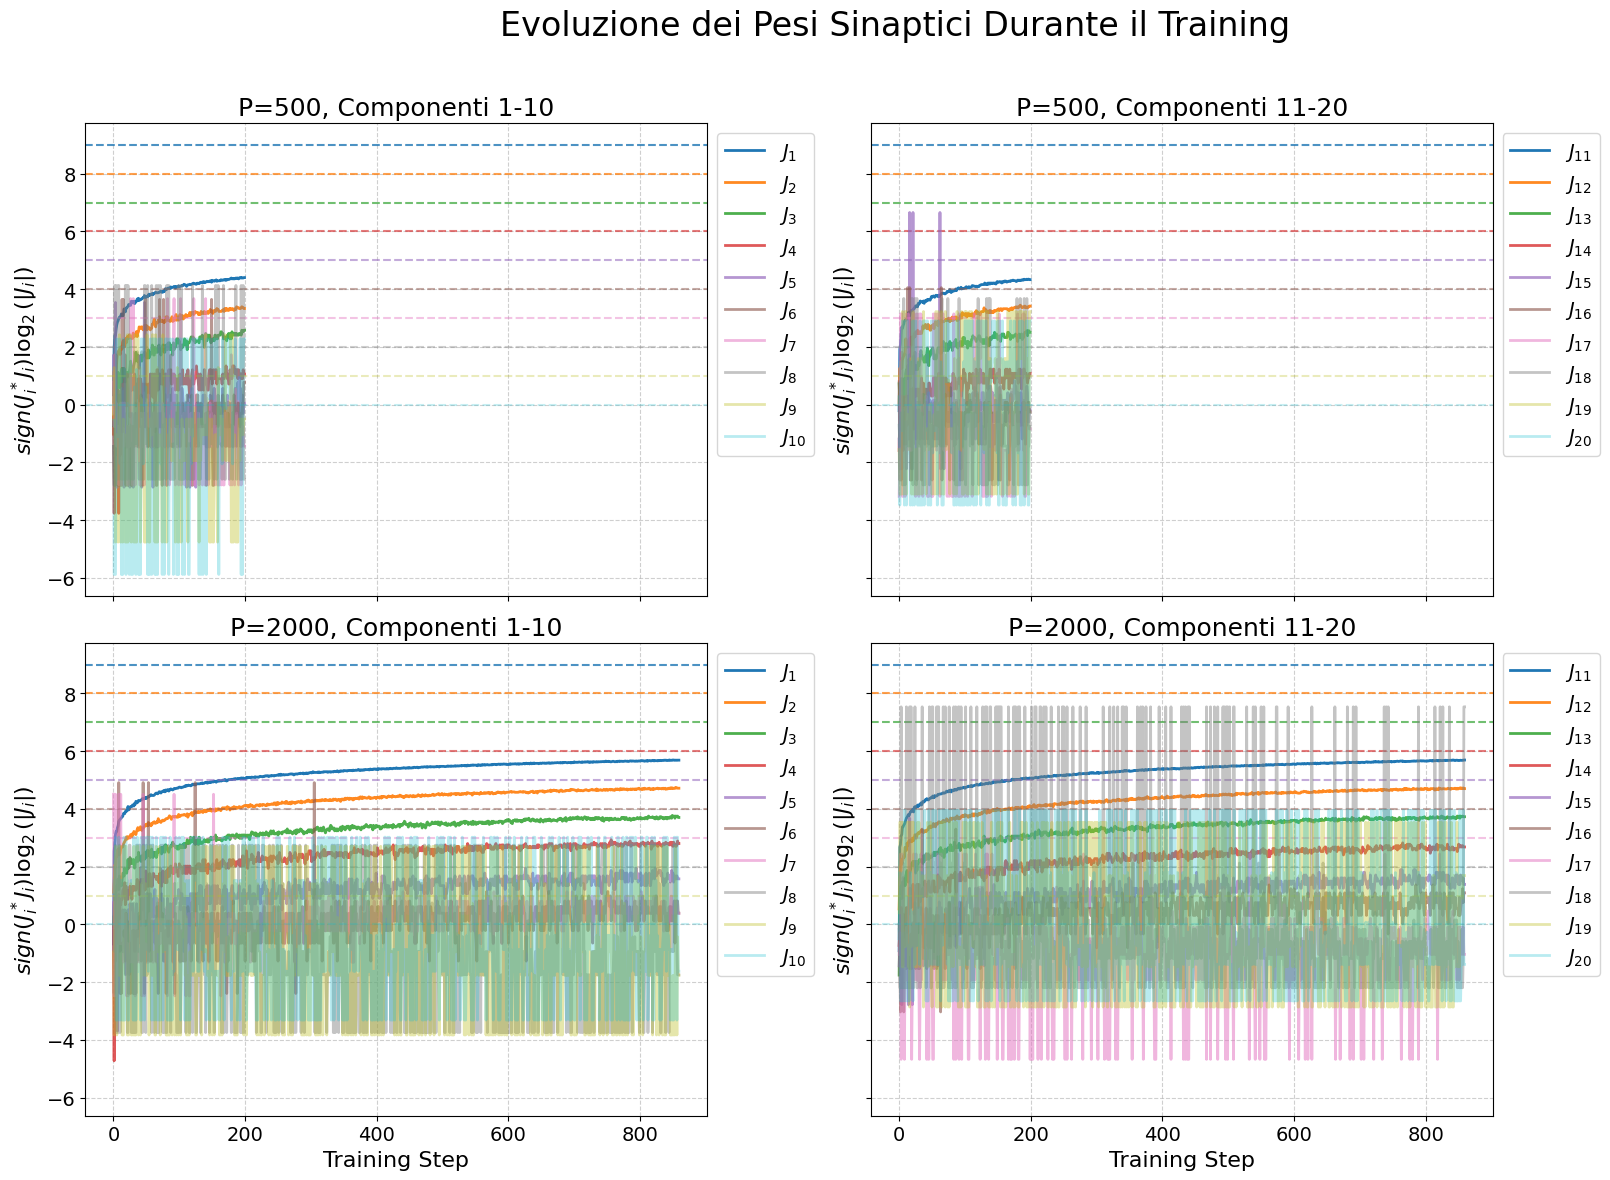

Salvataggio della figura in: confusion_matrices_grid_report.png


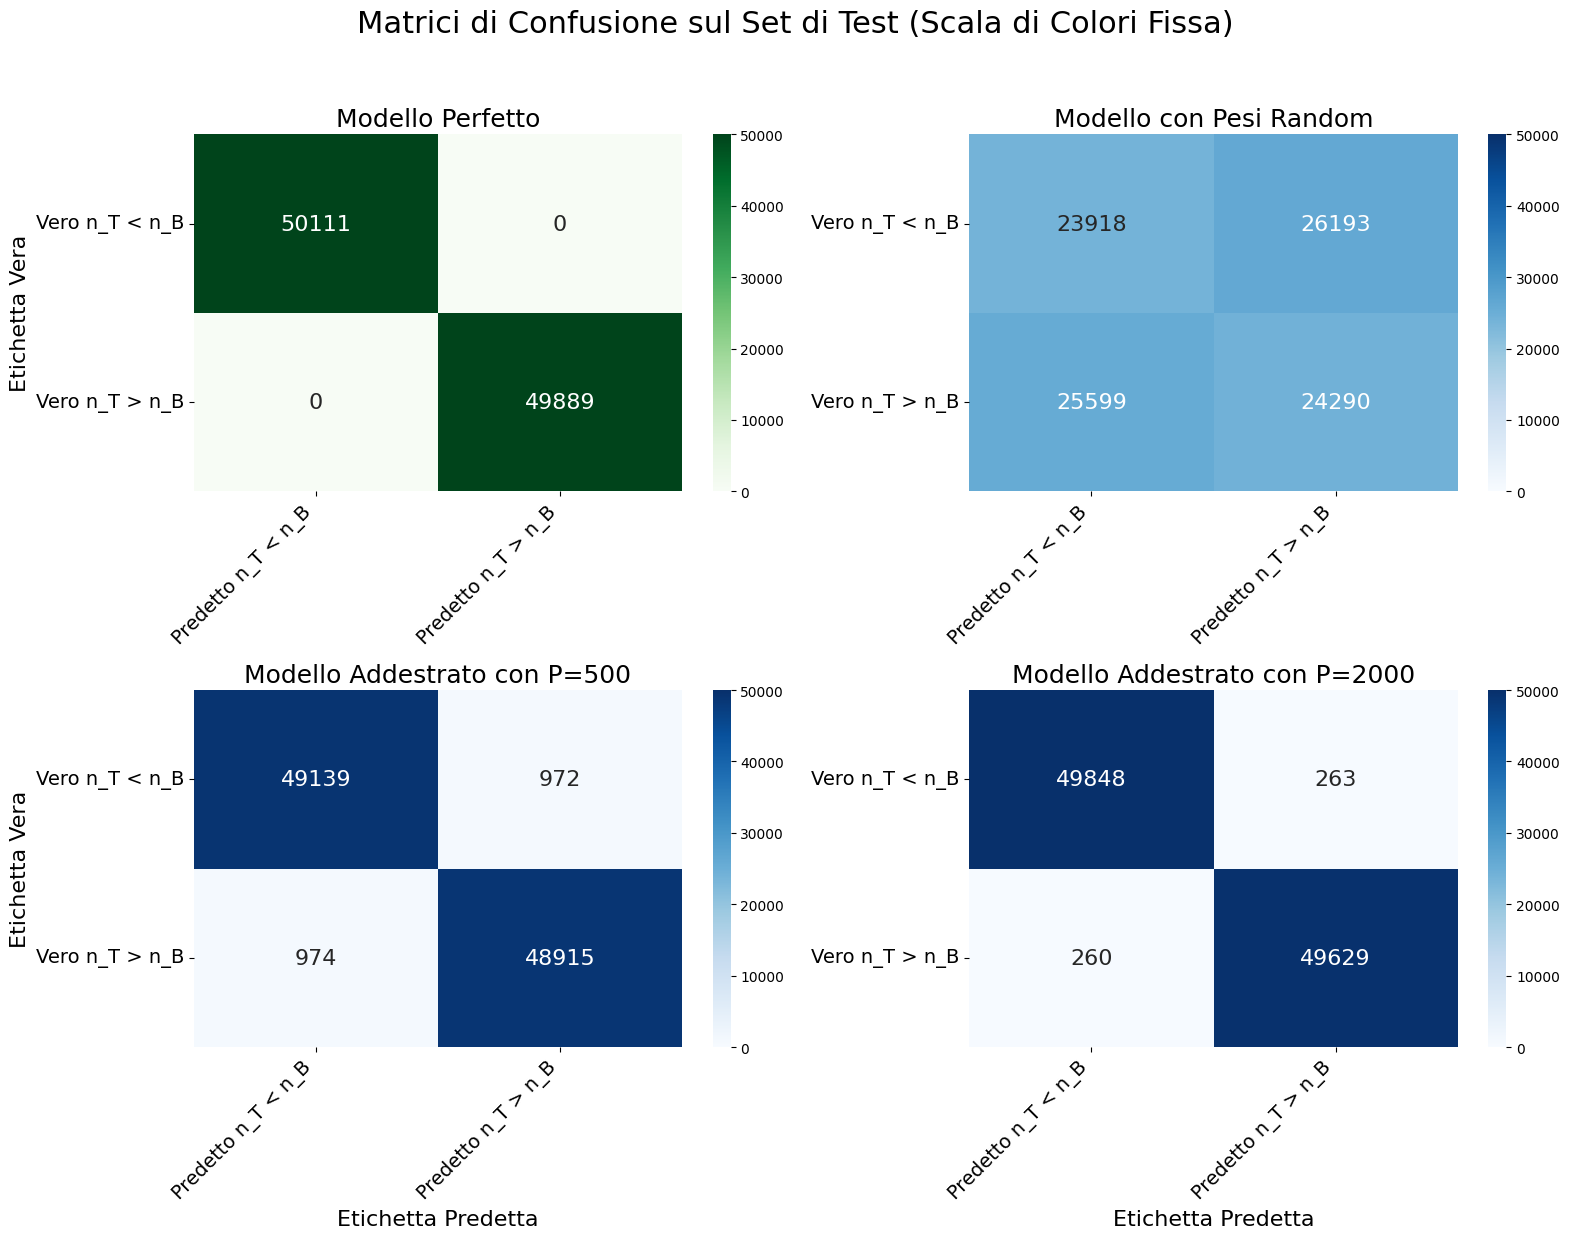

In [ ]:
experiment = Experiment("Confronto Training P=500 vs P=2000")
experiment.run()
experiment.plot_J_evolution()
experiment.plot_confusion_matrices()